# 02 · Análisis agronómico — Campo Trebolares

Exploración de los scores agronómicos para los 5 escenarios de cultivo,  
basados en el modelo FAO-56 (ETo Hargreaves-Samani) sobre la serie climática NASA POWER 2001–2025.

**Escenarios:** Maíz temprano · Maíz tardío · Trigo · Soja de primera · Soja de segunda

## 0 · Setup

In [1]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

ROOT = Path().resolve().parent
PROC = ROOT / 'data' / 'trebolares' / 'processed'

SCENARIOS = ['maize_early', 'maize_late', 'wheat', 'soy_first', 'soy_second']
LABELS = {
    'maize_early': 'Maíz temprano',
    'maize_late':  'Maíz tardío',
    'wheat':       'Trigo',
    'soy_first':   'Soja 1ª',
    'soy_second':  'Soja 2ª',
}
COLORS = {
    'maize_early': '#E8A838',
    'maize_late':  '#F4C97A',
    'wheat':       '#8B6914',
    'soy_first':   '#3A7D44',
    'soy_second':  '#83C27B',
}
CLASS_COLORS = {'Favorable': '#3A7D44', 'Intermedia': '#E8A838', 'Restrictiva': '#C0392B'}

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 4)})

print('ROOT:', ROOT)

ROOT: C:\Users\Usuario\OneDrive\appsheet\Antigravity\Proyecto ClimaData


## 1 · Carga de datos

In [2]:
metas = {}
campaign_summary = {}
stage_summary = {}
campaign_daily = {}

for sc in SCENARIOS:
    with open(PROC / f'agro_{sc}_meta.json') as f:
        metas[sc] = json.load(f)
    campaign_summary[sc] = pd.read_parquet(PROC / f'agro_{sc}_campaign_summary.parquet')
    stage_summary[sc]    = pd.read_parquet(PROC / f'agro_{sc}_stage_summary.parquet')
    campaign_daily[sc]   = pd.read_parquet(PROC / f'agro_{sc}_campaign_daily.parquet')

# Tabla unificada de campañas
cs_all = pd.concat(
    [df.assign(scenario=sc, scenario_label=LABELS[sc]) for sc, df in campaign_summary.items()],
    ignore_index=True
)

print(f'Escenarios cargados: {len(SCENARIOS)}')
print(f'Campañas x escenario: {len(campaign_summary["maize_early"])} ({campaign_summary["maize_early"]["campaign_start_year"].min()}–{campaign_summary["maize_early"]["campaign_start_year"].max()})')
print(f'Columnas campaign_summary: {list(campaign_summary["maize_early"].columns)}')

Escenarios cargados: 5
Campañas x escenario: 24 (2001–2024)
Columnas campaign_summary: ['campaign_start_year', 'campaign_label', 'precipitation_cycle_mm', 'eto_cycle_mm', 'etc_cycle_mm', 'mean_temp_cycle_c', 'cold_days_lt5', 'completeness_pct', 'precipitation_critical_mm', 'eto_critical_mm', 'etc_critical_mm', 'critical_negative_stage_count', 'worst_critical_balance_mm', 'water_balance_mm', 'critical_balance_mm', 'precip_to_etc_ratio', 'critical_precip_to_etc_ratio', 'critical_deficit_share', 'cold_days', 'score_cycle_component', 'score_critical_component', 'score_thermal_component', 'score_reliability_component', 'score_penalty_total', 'agro_score', 'campaign_class', 'score_driver', 'interpretation', 'scenario_label', 'crop_label']


## 2 · Resumen global por escenario

In [3]:
rows = []
for sc in SCENARIOS:
    gs = metas[sc]['global_summary']
    rows.append({
        'Cultivo':            gs['scenario_label'],
        'Score medio':        gs['mean_score'],
        'Banda':              gs['score_band'],
        'Favorables %':       gs['favorable_pct'],
        'Intermedias %':      gs['intermediate_pct'],
        'Restrictivas %':     gs['restrictive_pct'],
        'Balance medio (mm)': gs['mean_balance_mm'],
        'Mejor campaña':      gs['best_campaign'],
        'Peor campaña':       gs['worst_campaign'],
    })

summary_df = pd.DataFrame(rows).set_index('Cultivo')
summary_df.style \
    .background_gradient(subset=['Score medio'], cmap='RdYlGn', vmin=20, vmax=80) \
    .background_gradient(subset=['Balance medio (mm)'], cmap='RdYlGn', vmin=-500, vmax=0) \
    .format({'Score medio': '{:.1f}', 'Favorables %': '{:.0f}%',
             'Intermedias %': '{:.0f}%', 'Restrictivas %': '{:.0f}%',
             'Balance medio (mm)': '{:.0f}'})

,Score medio,Banda,Favorables %,Intermedias %,Restrictivas %,Balance medio (mm),Mejor campaña,Peor campaña
Cultivo,,,,,,,,
Maiz temprano,34.0,Restrictivo,0%,21%,79%,-343,2015/16,2017/18
Maiz tardio,44.5,Restrictivo,29%,17%,54%,-159,2016/17,2022/23
Trigo,40.4,Restrictivo,12%,12%,76%,-223,2016/16,2019/19
Soja de primera,44.5,Restrictivo,17%,21%,62%,-236,2015/16,2017/18
Soja de segunda,49.6,Intermedio,33%,17%,50%,-143,2011/12,2017/18


## 3 · Score medio por cultivo (barras)

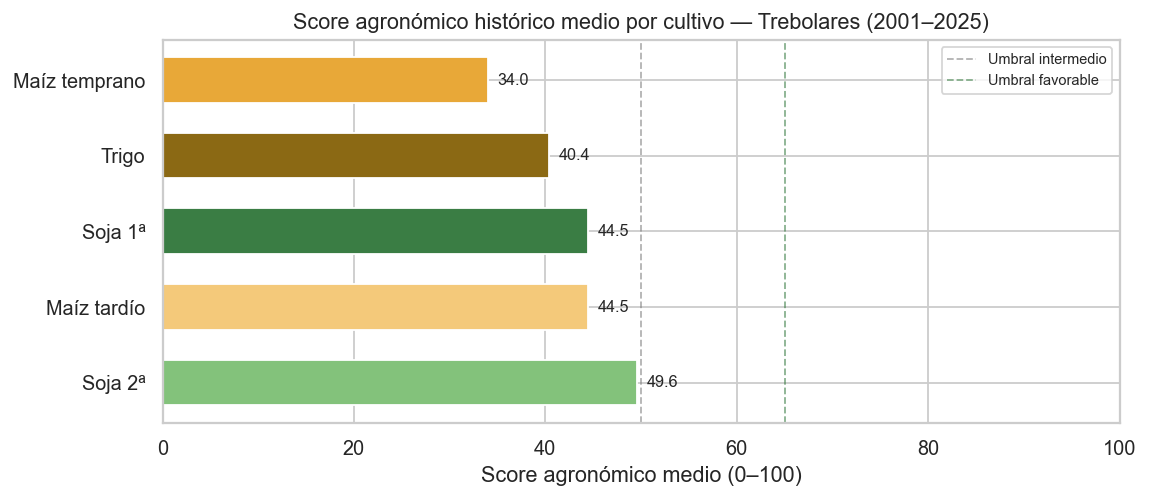

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))

scores = [(LABELS[sc], metas[sc]['global_summary']['mean_score'], COLORS[sc]) for sc in SCENARIOS]
scores.sort(key=lambda x: x[1], reverse=True)
labels_s, vals_s, colors_s = zip(*scores)

bars = ax.barh(labels_s, vals_s, color=colors_s, edgecolor='white', height=0.6)
ax.axvline(50, color='gray', lw=1, ls='--', alpha=0.6, label='Umbral intermedio')
ax.axvline(65, color='#3A7D44', lw=1, ls='--', alpha=0.6, label='Umbral favorable')

for bar, val in zip(bars, vals_s):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_xlim(0, 100)
ax.set_xlabel('Score agronómico medio (0–100)')
ax.set_title('Score agronómico histórico medio por cultivo — Trebolares (2001–2025)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4 · Distribución de clases por cultivo (stacked bar)

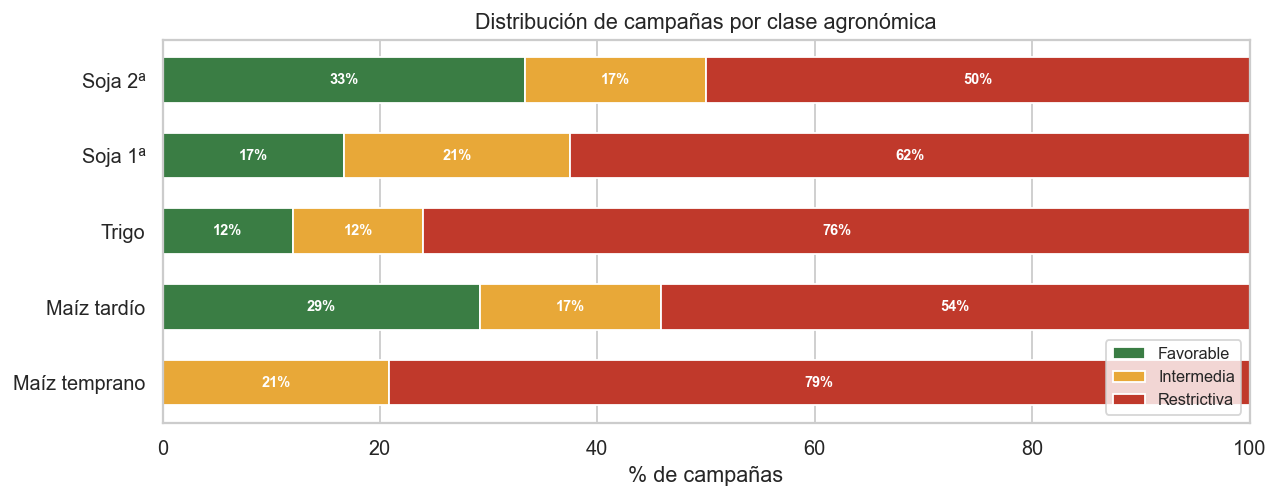

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))

class_df = (
    cs_all.groupby(['scenario_label', 'campaign_class'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Favorable', 'Intermedia', 'Restrictiva'])
)
# Normalizar a porcentaje
class_pct = class_df.div(class_df.sum(axis=1), axis=0) * 100
class_pct = class_pct.loc[[LABELS[sc] for sc in SCENARIOS]]

bottom = np.zeros(len(class_pct))
for col in ['Favorable', 'Intermedia', 'Restrictiva']:
    vals = class_pct[col].values
    ax.barh(class_pct.index, vals, left=bottom,
            color=CLASS_COLORS[col], label=col, edgecolor='white', height=0.6)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 8:
            ax.text(b + v/2, i, f'{v:.0f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xlim(0, 100)
ax.set_xlabel('% de campañas')
ax.set_title('Distribución de campañas por clase agronómica')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 5 · Evolución del score por campaña

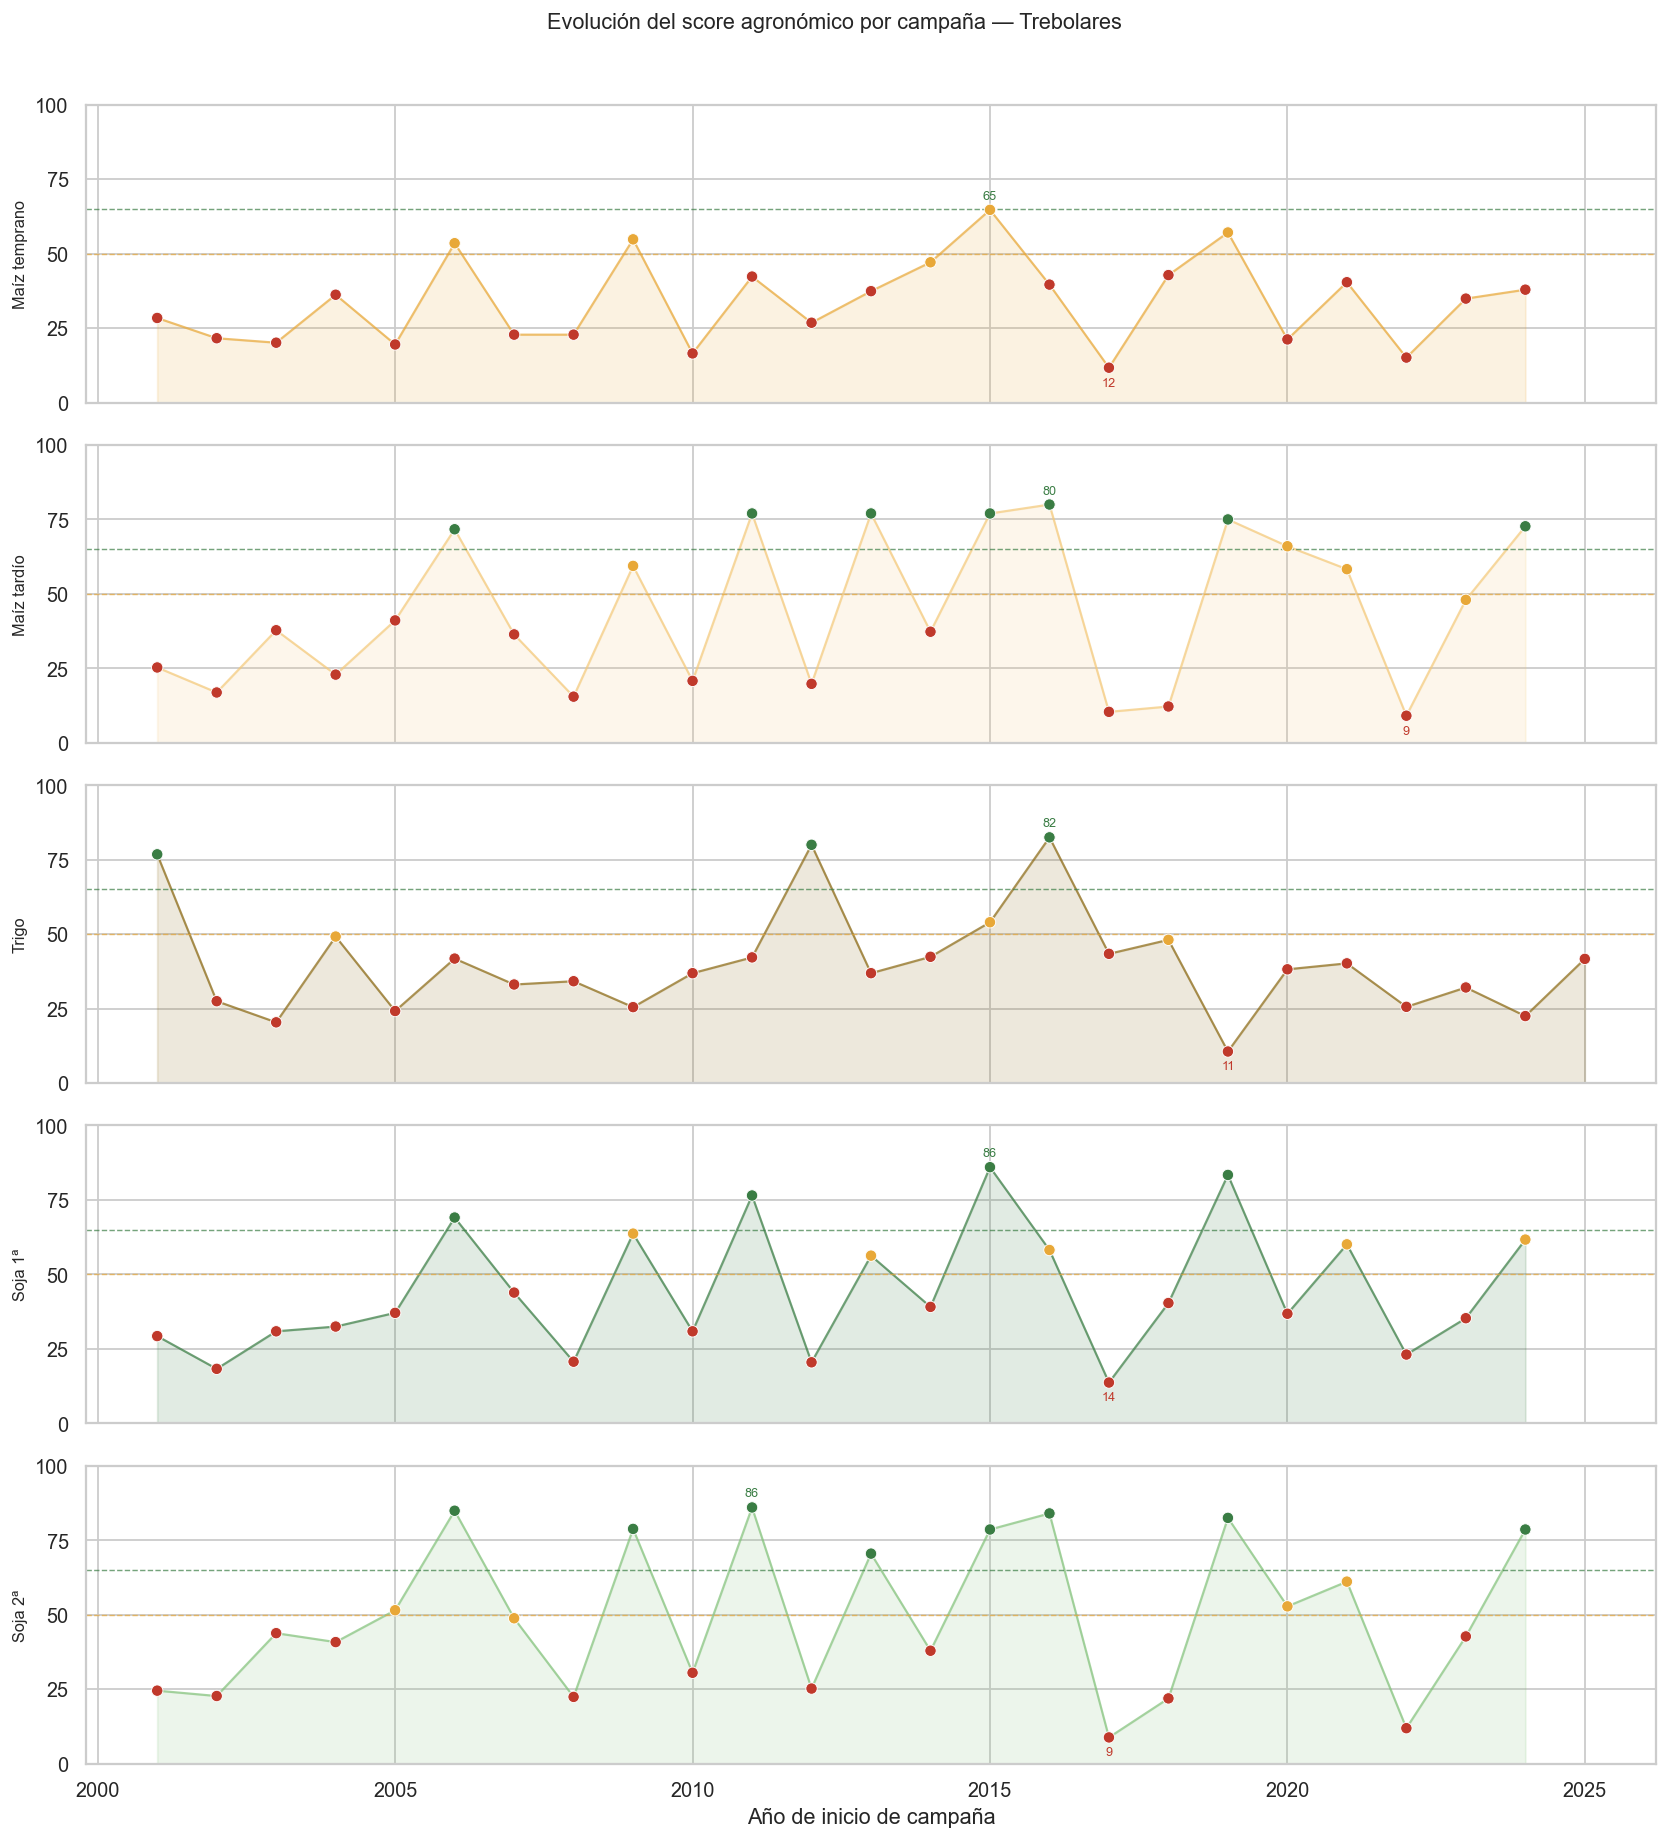

In [6]:
fig, axes = plt.subplots(len(SCENARIOS), 1, figsize=(13, 14), sharex=True)

for ax, sc in zip(axes, SCENARIOS):
    cs = campaign_summary[sc]
    x = cs['campaign_start_year']
    y = cs['agro_score']
    c = cs['campaign_class'].map(CLASS_COLORS)

    ax.fill_between(x, 0, y, alpha=0.15, color=COLORS[sc])
    ax.scatter(x, y, c=c, zorder=3, s=40, edgecolors='white', linewidths=0.5)
    ax.plot(x, y, color=COLORS[sc], lw=1.2, alpha=0.7)

    # Umbral líneas
    ax.axhline(50, color='#E8A838', lw=0.8, ls='--', alpha=0.7)
    ax.axhline(65, color='#3A7D44', lw=0.8, ls='--', alpha=0.7)

    # Anotar mejor y peor
    best_y  = cs.loc[cs['agro_score'].idxmax(), 'campaign_start_year']
    worst_y = cs.loc[cs['agro_score'].idxmin(), 'campaign_start_year']
    best_s  = cs.loc[cs['agro_score'].idxmax(), 'agro_score']
    worst_s = cs.loc[cs['agro_score'].idxmin(), 'agro_score']
    ax.annotate(f'{best_s:.0f}', xy=(best_y, best_s),
                xytext=(0, 6), textcoords='offset points',
                ha='center', fontsize=7, color='#3A7D44')
    ax.annotate(f'{worst_s:.0f}', xy=(worst_y, worst_s),
                xytext=(0, -10), textcoords='offset points',
                ha='center', fontsize=7, color='#C0392B')

    ax.set_ylim(0, 100)
    ax.set_ylabel(LABELS[sc], fontsize=9)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(25))

axes[-1].set_xlabel('Año de inicio de campaña')
fig.suptitle('Evolución del score agronómico por campaña — Trebolares', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6 · Boxplot de scores por cultivo

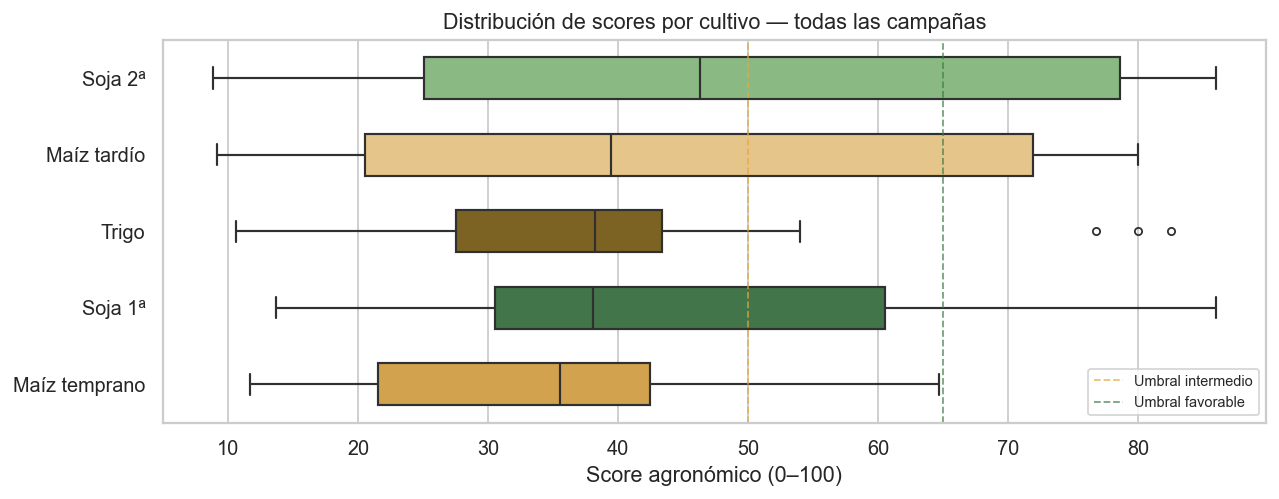

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))

order = sorted(LABELS.values(), key=lambda l: cs_all.loc[cs_all['scenario_label']==l, 'agro_score'].median(), reverse=True)
palette = {LABELS[sc]: COLORS[sc] for sc in SCENARIOS}

sns.boxplot(
    data=cs_all, x='agro_score', y='scenario_label',
    order=order, palette=palette,
    width=0.55, linewidth=1.2, fliersize=4, ax=ax
)
ax.axvline(50, color='#E8A838', lw=1, ls='--', alpha=0.7, label='Umbral intermedio')
ax.axvline(65, color='#3A7D44', lw=1, ls='--', alpha=0.7, label='Umbral favorable')
ax.set_xlabel('Score agronómico (0–100)')
ax.set_ylabel('')
ax.set_title('Distribución de scores por cultivo — todas las campañas')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7 · Balance hídrico por etapa — todos los cultivos

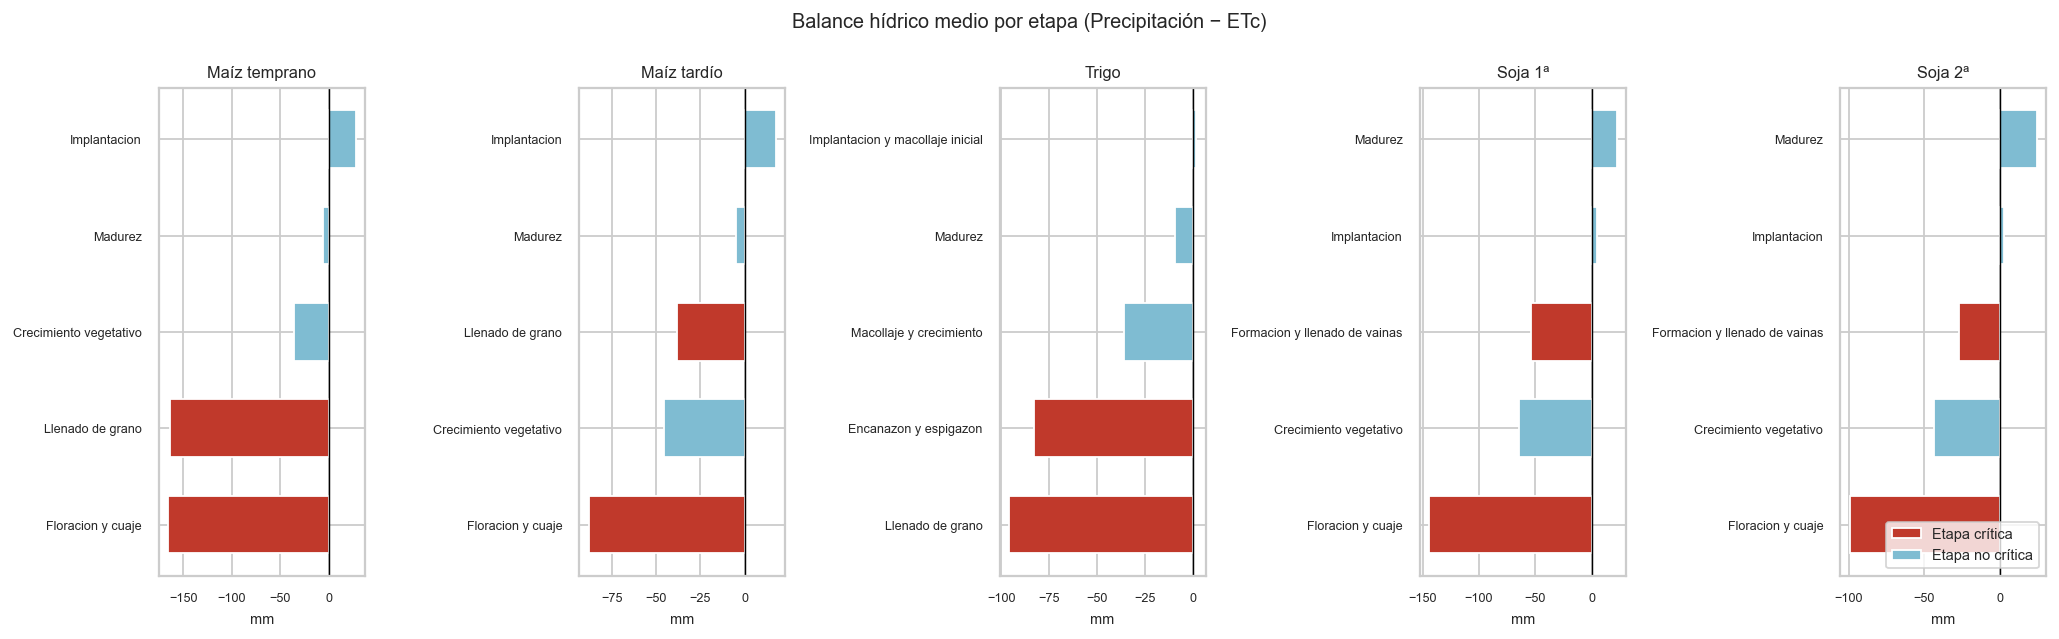

In [8]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 5), sharey=False)

for ax, sc in zip(axes, SCENARIOS):
    ss = stage_summary[sc].copy()
    stage_bal = (
        ss.groupby(['stage_label', 'is_critical_stage'])['water_balance_stage_mm']
        .mean()
        .reset_index()
        .sort_values('water_balance_stage_mm')
    )
    colors = ['#C0392B' if c else '#7FBCD2' for c in stage_bal['is_critical_stage']]
    bars = ax.barh(stage_bal['stage_label'], stage_bal['water_balance_stage_mm'],
                   color=colors, edgecolor='white', height=0.6)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(LABELS[sc], fontsize=9)
    ax.set_xlabel('mm', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)
    ax.tick_params(axis='x', labelsize=7)

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#C0392B', label='Etapa crítica'),
                   Patch(facecolor='#7FBCD2', label='Etapa no crítica')]
axes[-1].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle('Balance hídrico medio por etapa (Precipitación − ETc)', fontsize=11)
plt.tight_layout()
plt.show()

## 8 · Heatmap de scores — año × cultivo

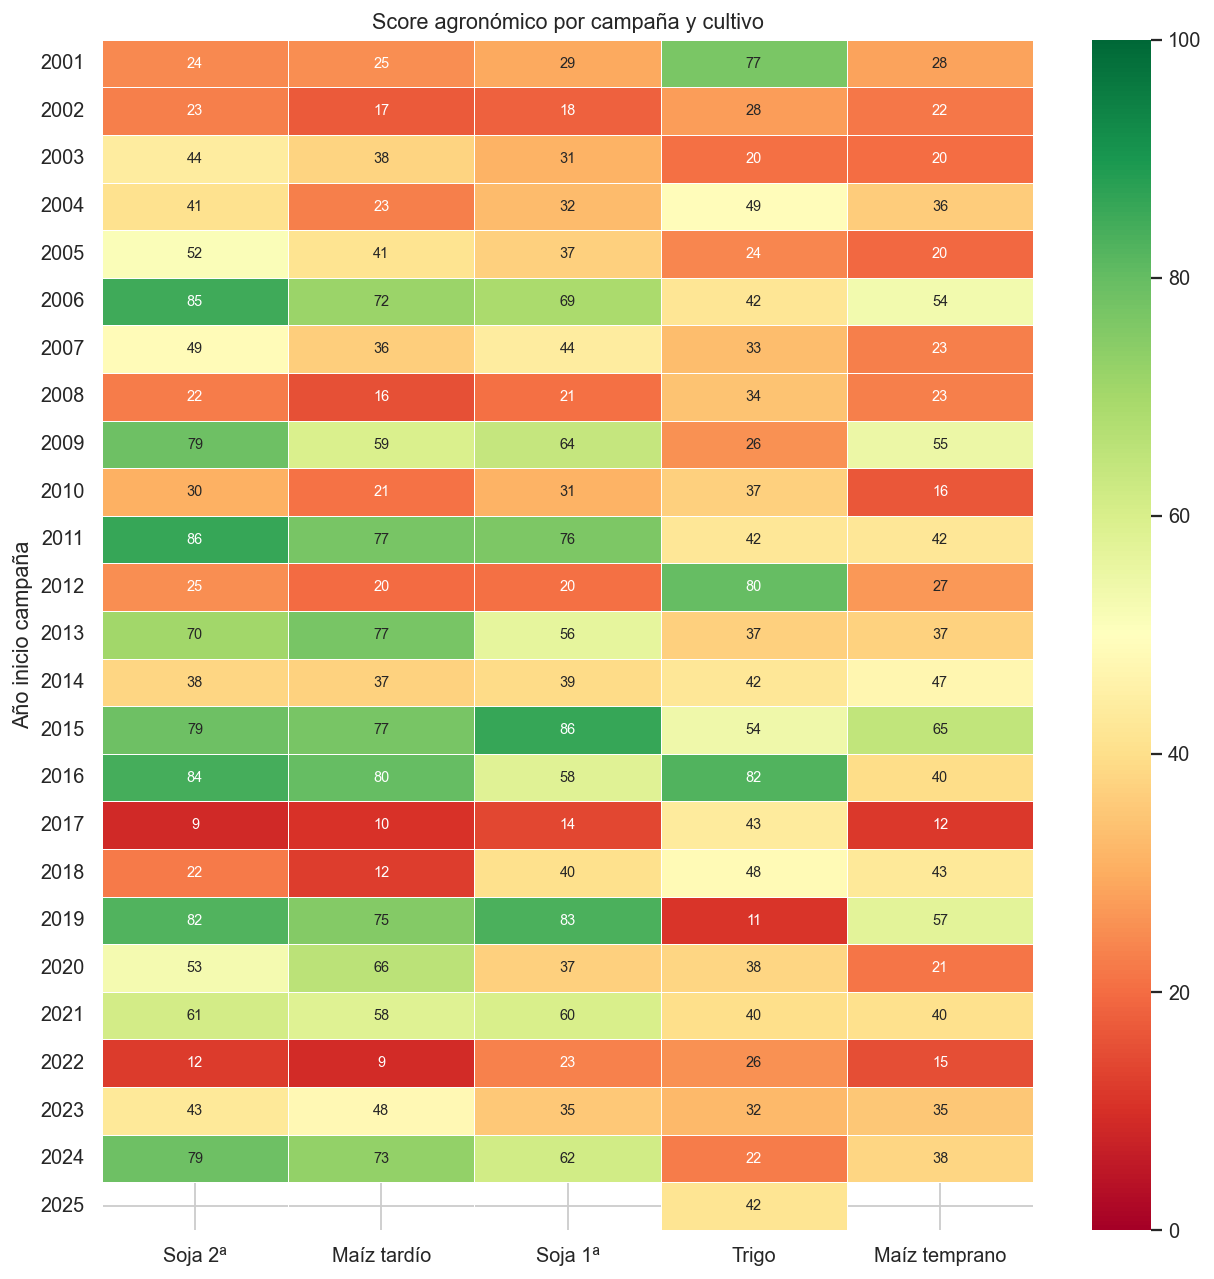

In [9]:
pivot = cs_all.pivot_table(
    index='campaign_start_year', columns='scenario_label', values='agro_score'
).rename(columns=LABELS)

# Ordenar columnas por score medio descendente
col_order = cs_all.groupby('scenario_label')['agro_score'].mean().sort_values(ascending=False).index.tolist()
pivot = pivot[[c for c in col_order if c in pivot.columns]]

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(
    pivot, annot=True, fmt='.0f', cmap='RdYlGn',
    vmin=0, vmax=100, linewidths=0.4, linecolor='white',
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Score agronómico por campaña y cultivo', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Año inicio campaña')
plt.tight_layout()
plt.show()

## 9 · Correlación score vs precipitación del ciclo

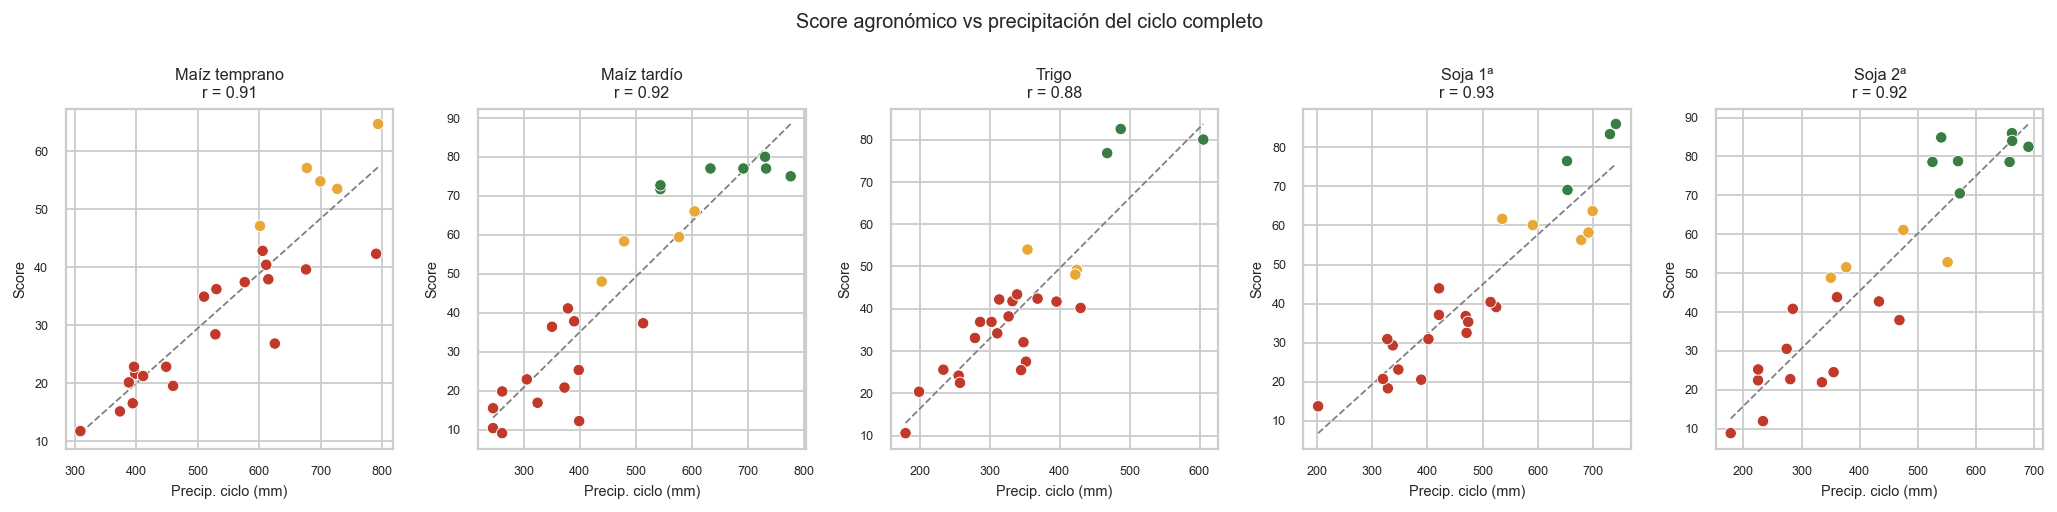

In [10]:
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(16, 4), sharey=False)

for ax, sc in zip(axes, SCENARIOS):
    cs = campaign_summary[sc]
    c = cs['campaign_class'].map(CLASS_COLORS)
    ax.scatter(cs['precipitation_cycle_mm'], cs['agro_score'],
               c=c, s=40, edgecolors='white', linewidths=0.5, zorder=3)

    # Línea de tendencia
    m, b = np.polyfit(cs['precipitation_cycle_mm'], cs['agro_score'], 1)
    x_line = np.linspace(cs['precipitation_cycle_mm'].min(), cs['precipitation_cycle_mm'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='gray', lw=1, ls='--')

    r = cs[['precipitation_cycle_mm', 'agro_score']].corr().iloc[0, 1]
    ax.set_title(f'{LABELS[sc]}\nr = {r:.2f}', fontsize=9)
    ax.set_xlabel('Precip. ciclo (mm)', fontsize=8)
    ax.set_ylabel('Score', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('Score agronómico vs precipitación del ciclo completo', fontsize=11)
plt.tight_layout()
plt.show()

## 10 · Componentes del score — contribución media por cultivo

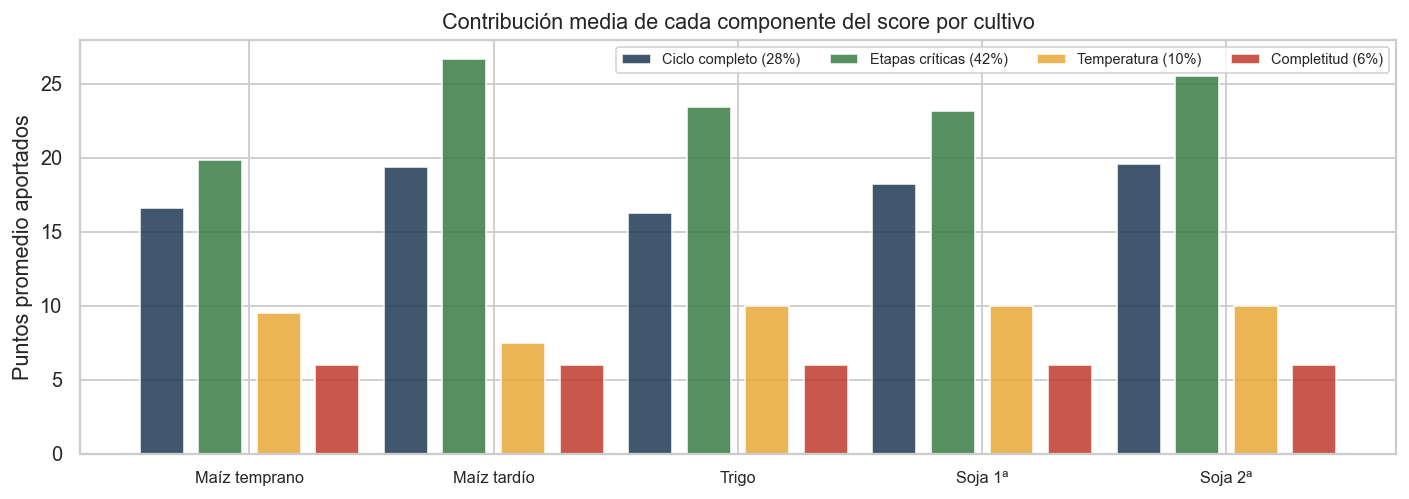

In [11]:
component_cols = [
    'score_cycle_component',
    'score_critical_component',
    'score_thermal_component',
    'score_reliability_component',
]
component_labels = ['Ciclo completo\n(28%)', 'Etapas críticas\n(42%)', 'Temperatura\n(10%)', 'Completitud\n(6%)']

comp_means = {
    LABELS[sc]: campaign_summary[sc][component_cols].mean().values
    for sc in SCENARIOS
}
comp_df = pd.DataFrame(comp_means, index=component_labels).T

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(comp_df))
width = 0.18
offsets = np.linspace(-0.36, 0.36, 4)

component_colors = ['#1E3953', '#3A7D44', '#E8A838', '#C0392B']
for i, (col_label, color) in enumerate(zip(component_labels, component_colors)):
    vals = comp_df[col_label].values if col_label in comp_df.columns else comp_df.iloc[:, i].values
    ax.bar(x + offsets[i], comp_df.iloc[:, i].values, width,
           label=col_label.replace('\n', ' '), color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comp_df.index, fontsize=9)
ax.set_ylabel('Puntos promedio aportados')
ax.set_title('Contribución media de cada componente del score por cultivo')
ax.legend(fontsize=8, ncol=4)
plt.tight_layout()
plt.show()

## 11 · Campañas sincronizadas — años buenos y malos en todos los cultivos

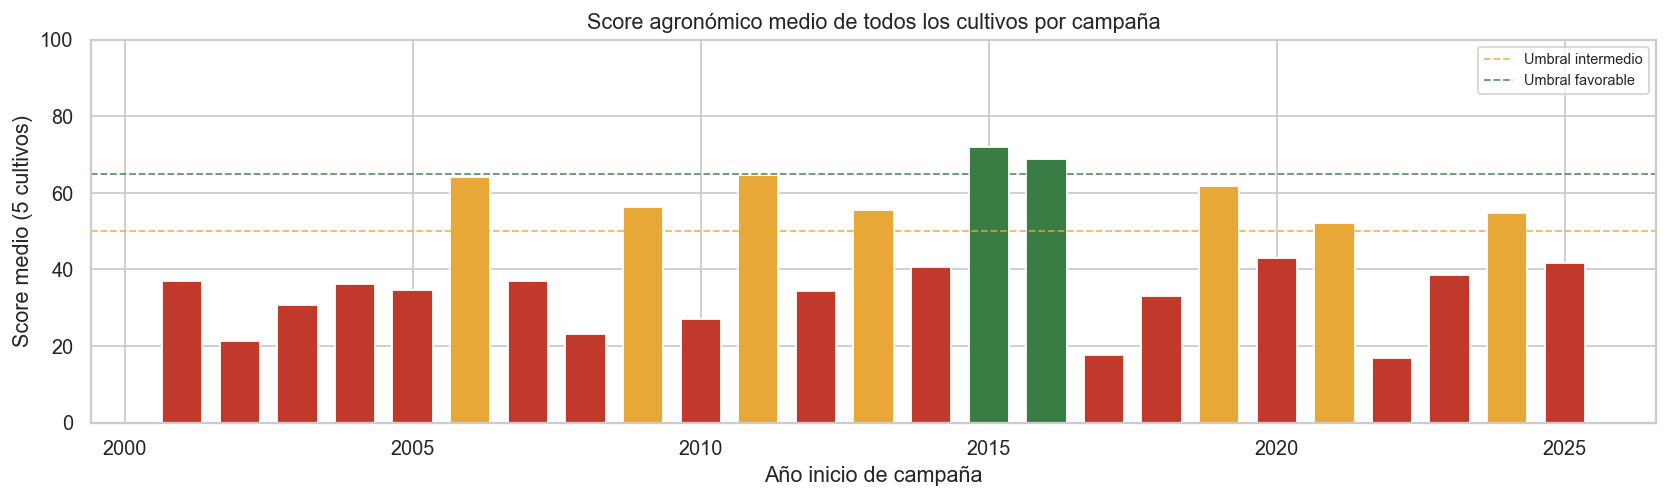

Top 5 mejores campañas (promedio todos los cultivos):
 campaign_start_year  mean_score_all
                2015           72.06
                2016           68.86
                2011           64.80
                2006           64.20
                2019           61.72

Top 5 peores campañas:
 campaign_start_year  mean_score_all
                2022           16.96
                2017           17.60
                2002           21.40
                2008           23.12
                2010           27.12


In [12]:
# Score medio de todos los cultivos por año
mean_score_by_year = (
    cs_all.groupby('campaign_start_year')['agro_score']
    .mean()
    .reset_index()
    .rename(columns={'agro_score': 'mean_score_all'})
)

fig, ax = plt.subplots(figsize=(13, 4))
x = mean_score_by_year['campaign_start_year']
y = mean_score_by_year['mean_score_all']
colors_bar = ['#3A7D44' if v >= 65 else '#E8A838' if v >= 50 else '#C0392B' for v in y]

ax.bar(x, y, color=colors_bar, edgecolor='white', width=0.7)
ax.axhline(50, color='#E8A838', lw=1, ls='--', alpha=0.8, label='Umbral intermedio')
ax.axhline(65, color='#3A7D44', lw=1, ls='--', alpha=0.8, label='Umbral favorable')
ax.set_ylim(0, 100)
ax.set_xlabel('Año inicio de campaña')
ax.set_ylabel('Score medio (5 cultivos)')
ax.set_title('Score agronómico medio de todos los cultivos por campaña')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Top 5 mejores y peores
print('Top 5 mejores campañas (promedio todos los cultivos):')
print(mean_score_by_year.nlargest(5, 'mean_score_all').to_string(index=False))
print()
print('Top 5 peores campañas:')
print(mean_score_by_year.nsmallest(5, 'mean_score_all').to_string(index=False))

## 12 · Análisis de la campaña 2017/18 — la peor sincronizada

In [13]:
WORST_YEAR = 2017

print(f'Campaña {WORST_YEAR}/{WORST_YEAR+1} — detalle por cultivo:')
worst = cs_all[cs_all['campaign_start_year'] == WORST_YEAR][[
    'scenario_label', 'agro_score', 'campaign_class', 'precipitation_cycle_mm',
    'water_balance_mm', 'critical_balance_mm', 'score_driver'
]].set_index('scenario_label')
print(worst.to_string())

# Comparar con la mejor campaña de maíz tardío (2016/17)
print()
BEST_YEAR = 2016
print(f'Campaña {BEST_YEAR}/{BEST_YEAR+1} (mejor maíz tardío) — detalle por cultivo:')
best = cs_all[cs_all['campaign_start_year'] == BEST_YEAR][[
    'scenario_label', 'agro_score', 'campaign_class', 'precipitation_cycle_mm',
    'water_balance_mm', 'critical_balance_mm'
]].set_index('scenario_label')
print(best.to_string())

Campaña 2017/2018 — detalle por cultivo:
                agro_score campaign_class  precipitation_cycle_mm  water_balance_mm  critical_balance_mm                                  score_driver
scenario_label                                                                                                                                        
Maíz temprano         11.7    Restrictiva                  308.64            -600.9               -500.1        Deficit fuerte en floracion y llenado.
Maíz tardío           10.4    Restrictiva                  245.31            -422.7               -340.9        Deficit fuerte en floracion y llenado.
Trigo                 43.4    Restrictiva                  338.96            -195.6               -147.4  Etapas criticas con oferta hidrica ajustada.
Soja 1ª               13.7    Restrictiva                  201.84            -567.5               -362.0        Deficit fuerte en floracion y llenado.
Soja 2ª                8.8    Restrictiva            

## 13 · Mensajes agronómicos finales

In [14]:
for sc in SCENARIOS:
    gs = metas[sc]['global_summary']
    print(f"{'='*60}")
    print(f"  {gs['scenario_label'].upper()}")
    print(f"  Score medio: {gs['mean_score']:.1f} | Banda: {gs['score_band']}")
    print(f"  {gs['executive_message']}")
    print(f"  Limitante: {gs['dominant_driver']}")
    print()

  MAIZ TEMPRANO
  Score medio: 34.0 | Banda: Restrictivo
  La serie historica ubica al punto en una franja restrictiva para maiz temprano bajo los supuestos actuales.
  Limitante: El principal limitante historico aparece en floracion y llenado, donde la oferta de agua suele quedar corta.

  MAIZ TARDIO
  Score medio: 44.5 | Banda: Restrictivo
  La serie historica ubica al punto en una franja restrictiva para maiz tardio bajo los supuestos actuales.
  Limitante: El principal limitante historico aparece en floracion y llenado, donde la oferta de agua suele quedar corta.

  TRIGO
  Score medio: 40.4 | Banda: Restrictivo
  La serie historica ubica al punto en una franja restrictiva para trigo bajo los supuestos actuales.
  Limitante: El principal limitante historico aparece en encanazon, espigazon y llenado, donde la oferta de agua suele quedar corta.

  SOJA DE PRIMERA
  Score medio: 44.5 | Banda: Restrictivo
  La serie historica ubica al punto en una franja restrictiva para soja de prime